# Dropping the windows that are mostly `unknown`

A window a person left largely unlabelled says little about whether the model calls breath
phases correctly - most of its samples are an absence rather than a phase. This asks what the
picture looks like once those windows are set aside.

**The rule:** drop a window whose *labels* are more than a given fraction `unknown`. The
headline cut is **0.5**, and a sweep follows because the cut point is the whole question.

**What is measured:** the confusion of `inhale`, `exhale` and `stop`, before and after. Rows
are what the labeller called; the `unknown` **column** is kept, because a phase predicted as
`unknown` is the model falling silent over a real breath and dropping that column would hide
the commonest error there is.

Nothing here is trained or retrained - it re-scores the saved logits over a subset of windows.

In [1]:
import sys
from pathlib import Path


def repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'phase').is_dir():
            return candidate
    raise RuntimeError(f'no inhale-exhale-training checkout at or above {start}')


REPO = repo_root(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

try:
    import torch  # noqa: F401
except ModuleNotFoundError as missing:
    raise RuntimeError(
        f'{missing.name} is missing - select the inhale-exhale-training kernel') from missing
print(f'repo root {REPO}')

repo root /Users/yaelalon/inhale-exhale-training


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image

import report_folds as rf
from models.lightning_module import allowed_for
from phase.decode import decode, transition_matrix
from phase.figures import GRID, INK, INK_SOFT, SURFACE
from phase.labels import PHASES, UNKNOWN

OUT = REPO / 'out' / 'unknown_filter'
OUT.mkdir(parents=True, exist_ok=True)

runs = sorted((REPO / 'outputs').glob('*/fold_0/test_logits.npz'),
              key=lambda p: p.stat().st_mtime)
RUN = runs[-1].parent.parent
folds = [rf.load_fold(d) for d in sorted(RUN.iterdir())
         if d.is_dir() and (d / rf.LOGITS_NAME).exists()]

# The run's own Hydra config, never `parameter/`: that tree is what the next run will use and
# it moves, so reading it here would rescore this run under settings it never saw.
cfg = rf.config_of(RUN)
decoding = rf.decoding_of(RUN)
SOURCE = rf.label_source_of(RUN)
COST = transition_matrix(allowed_for(decoding, SOURCE), decoding['switch_penalty'])
MIN_DURATION = decoding['min_duration']
FPS = float(np.median(folds[0]['fps']))
EVENT_IOU = float(cfg.training.event_iou)

ensemble = {**folds[0],
            'logits': np.stack([f['logits'] for f in folds]).mean(axis=0)}
windows = rf.windows_of(ensemble)
print(f'run {RUN.name}: {len(folds)} folds, {len(windows)} test windows, '
      f'{len(np.unique(ensemble["patient"]))} patients, labels.source={SOURCE}')

run run_215005: 5 folds, 228 test windows, 15 patients, labels.source=human


## How much of each window is `unknown`?

In the labels, not the predictions - the question is whether the window carries information,
which is a property of what the person marked.

In [3]:
share = np.array([float((truth == UNKNOWN).mean()) for _, truth in windows])
frame = pd.DataFrame({
    'patient': ensemble['patient'], 'window': ensemble['window_id'],
    'env': ensemble['env'], 'unknown_share': share,
    'samples': [len(t) for _, t in windows]})

THRESHOLD = 0.5
frame['kept'] = frame.unknown_share <= THRESHOLD
frame.to_csv(OUT / 'window_unknown_share.csv', index=False)

print(frame.unknown_share.describe()[['min', '25%', '50%', '75%', 'max']].round(3).to_string())
print()
for edge in (0.0, 0.1, 0.25, 0.5, 0.75, 0.9):
    print(f'  windows over {edge:.0%} unknown: {int((share > edge).sum()):3d} '
          f'of {len(share)}')
print()
print(f'at the {THRESHOLD:.0%} cut: keep {int(frame.kept.sum())}, '
      f'drop {int((~frame.kept).sum())}')
print(f'entirely unknown windows: {int((share == 1.0).sum())}')

min    0.000
25%    0.000
50%    0.045
75%    0.348
max    1.000

  windows over 0% unknown: 130 of 228
  windows over 10% unknown: 103 of 228
  windows over 25% unknown:  67 of 228
  windows over 50% unknown:  46 of 228
  windows over 75% unknown:  34 of 228
  windows over 90% unknown:  34 of 228

at the 50% cut: keep 182, drop 46
entirely unknown windows: 34


## The confusion of the three called phases, before and after

Row-normalised, so each row reads as "of the samples the labeller called X, where did the
model put them". The `unknown` column stays.

In [4]:
def called_confusion(subset) -> np.ndarray:
    """Rows: inhale / exhale / stop as labelled. Columns: all four, so the silence shows."""
    called = [PHASES.index(n) for n in PHASES if PHASES.index(n) != UNKNOWN]
    matrix = np.zeros((len(called), len(PHASES)))
    for logits, truth in subset:
        prediction = decode(logits, COST, MIN_DURATION)
        for row, true_class in enumerate(called):
            picked = truth == true_class
            if not picked.any():
                continue
            for predicted in range(len(PHASES)):
                matrix[row, predicted] += float((prediction[picked] == predicted).sum())
    totals = matrix.sum(axis=1, keepdims=True)
    return np.divide(matrix, totals, out=np.zeros_like(matrix), where=totals > 0)


before = [w for w in windows]
after = [w for w, keep in zip(windows, frame.kept) if keep]

cm_before, cm_after = called_confusion(before), called_confusion(after)
scores = {
    'before': rf.score_windows(before, COST, MIN_DURATION, FPS, EVENT_IOU),
    'after': rf.score_windows(after, COST, MIN_DURATION, FPS, EVENT_IOU),
}
keep = ['macro_f1', 'accuracy', *[f'f1_{n}' for n in PHASES],
        *[f'event_f1_{n}' for n in PHASES], 'boundary_mae_sec']
table = pd.DataFrame([
    {'metric': m, 'before': scores['before'].get(m, np.nan),
     'after': scores['after'].get(m, np.nan),
     'delta': scores['after'].get(m, np.nan) - scores['before'].get(m, np.nan)}
    for m in keep if m in scores['before']])
table.to_csv(OUT / 'before_after.csv', index=False)
table.set_index('metric').round(3)

,before,after,delta
metric,,,
macro_f1,0.844,0.781,-0.064
accuracy,0.856,0.829,-0.027
f1_unknown,0.856,0.588,-0.268
f1_inhale,0.911,0.915,0.005
f1_exhale,0.861,0.866,0.005
f1_stop,0.750,0.754,0.004
event_f1_unknown,0.341,0.205,-0.136
event_f1_inhale,0.797,0.944,0.147
event_f1_exhale,0.758,0.903,0.145


/var/folders/8b/sj87tkf90m16zft163pkt0ww0000gn/T/ipykernel_28996/1485471099.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.93))


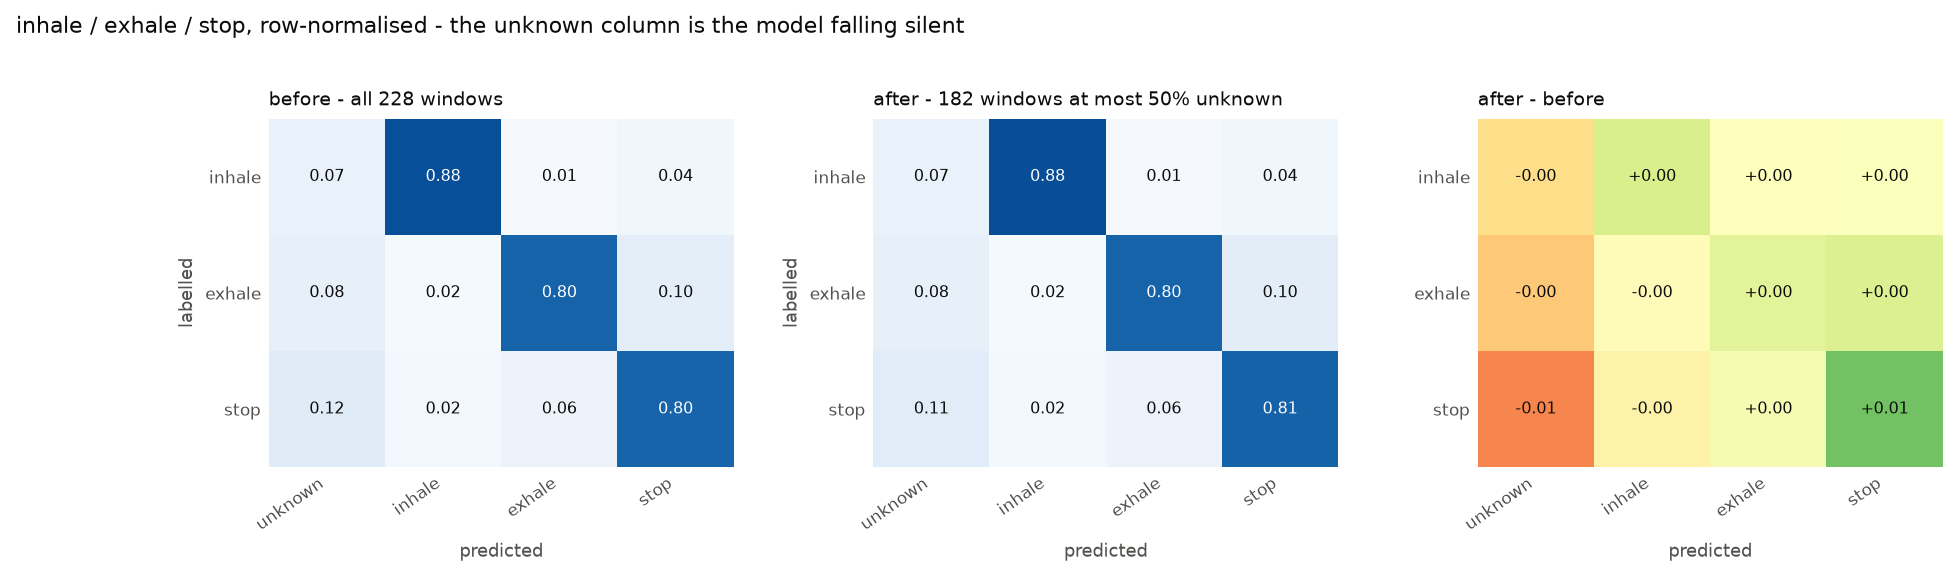

In [5]:
CALLED = [n for n in PHASES if PHASES.index(n) != UNKNOWN]


def draw_pair(cm_a, cm_b, labels, out_path, subtitle_a, subtitle_b):
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5), facecolor=SURFACE,
                             gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.30})
    for ax, matrix, title in zip(axes[:2], (cm_a, cm_b), (subtitle_a, subtitle_b)):
        ax.imshow(matrix, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(len(PHASES)), PHASES, fontsize=7.5, rotation=35, ha='right')
        ax.set_yticks(range(len(CALLED)), CALLED, fontsize=7.5)
        ax.set_xlabel('predicted', fontsize=8, color=INK_SOFT)
        ax.set_ylabel('labelled', fontsize=8, color=INK_SOFT)
        ax.set_title(title, fontsize=8.5, color=INK, loc='left', pad=6)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center', fontsize=7,
                        color=SURFACE if matrix[i, j] > 0.55 else INK)
        ax.tick_params(colors=INK_SOFT, length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

    delta = cm_b - cm_a
    widest = max(float(np.abs(delta).max()), 0.01)
    axes[2].imshow(delta, cmap='RdYlGn', vmin=-widest, vmax=widest)
    axes[2].set_xticks(range(len(PHASES)), PHASES, fontsize=7.5, rotation=35, ha='right')
    axes[2].set_yticks(range(len(CALLED)), CALLED, fontsize=7.5)
    axes[2].set_xlabel('predicted', fontsize=8, color=INK_SOFT)
    axes[2].set_title('after - before', fontsize=8.5, color=INK, loc='left', pad=6)
    for i in range(delta.shape[0]):
        for j in range(delta.shape[1]):
            axes[2].text(j, i, f'{delta[i, j]:+.2f}', ha='center', va='center', fontsize=7,
                         color=INK)
    axes[2].tick_params(colors=INK_SOFT, length=0)
    for spine in axes[2].spines.values():
        spine.set_visible(False)

    fig.suptitle('inhale / exhale / stop, row-normalised - the unknown column is the '
                 'model falling silent', fontsize=10, color=INK, x=0.008, ha='left', y=0.99)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    fig.savefig(out_path, dpi=160, facecolor=SURFACE, bbox_inches='tight')
    plt.close(fig)
    return Image(filename=str(out_path))


draw_pair(cm_before, cm_after, CALLED, OUT / 'confusion_before_after.png',
          f'before - all {len(before)} windows',
          f'after - {len(after)} windows at most {THRESHOLD:.0%} unknown')

## Where the cut should be

The 0.5 threshold is a choice, so here is the whole curve. `kept` falls as the rule tightens;
if a metric only rises because the easy windows are all that remain, that shows up as the two
moving together.

In [6]:
rows = []
for edge in (1.0, 0.9, 0.75, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0):
    subset = [w for w, s in zip(windows, share) if s <= edge]
    if len(subset) < 10:
        continue
    scored = rf.score_windows(subset, COST, MIN_DURATION, FPS, EVENT_IOU)
    rows.append({'threshold': edge, 'kept': len(subset),
                 'kept_pct': 100 * len(subset) / len(windows),
                 'macro_f1': scored['macro_f1'], 'accuracy': scored['accuracy'],
                 **{f'f1_{n}': scored[f'f1_{n}'] for n in PHASES}})
sweep = pd.DataFrame(rows)
sweep.to_csv(OUT / 'threshold_sweep.csv', index=False)
sweep.set_index('threshold').round(3)

,kept,kept_pct,macro_f1,accuracy,f1_unknown,f1_inhale,f1_exhale,f1_stop
threshold,,,,,,,,
1.00,228,100.000,0.844,0.856,0.856,0.911,0.861,0.750
0.90,194,85.088,0.799,0.829,0.668,0.913,0.862,0.751
0.75,194,85.088,0.799,0.829,0.668,0.913,0.862,0.751
0.60,186,81.579,0.784,0.828,0.607,0.914,0.864,0.753
0.50,182,79.825,0.781,0.829,0.588,0.915,0.866,0.754
0.40,176,77.193,0.773,0.830,0.553,0.917,0.867,0.757
0.30,165,72.368,0.760,0.833,0.487,0.921,0.870,0.761
0.20,149,65.351,0.733,0.844,0.359,0.932,0.878,0.762
0.10,125,54.825,0.681,0.862,0.120,0.942,0.889,0.773


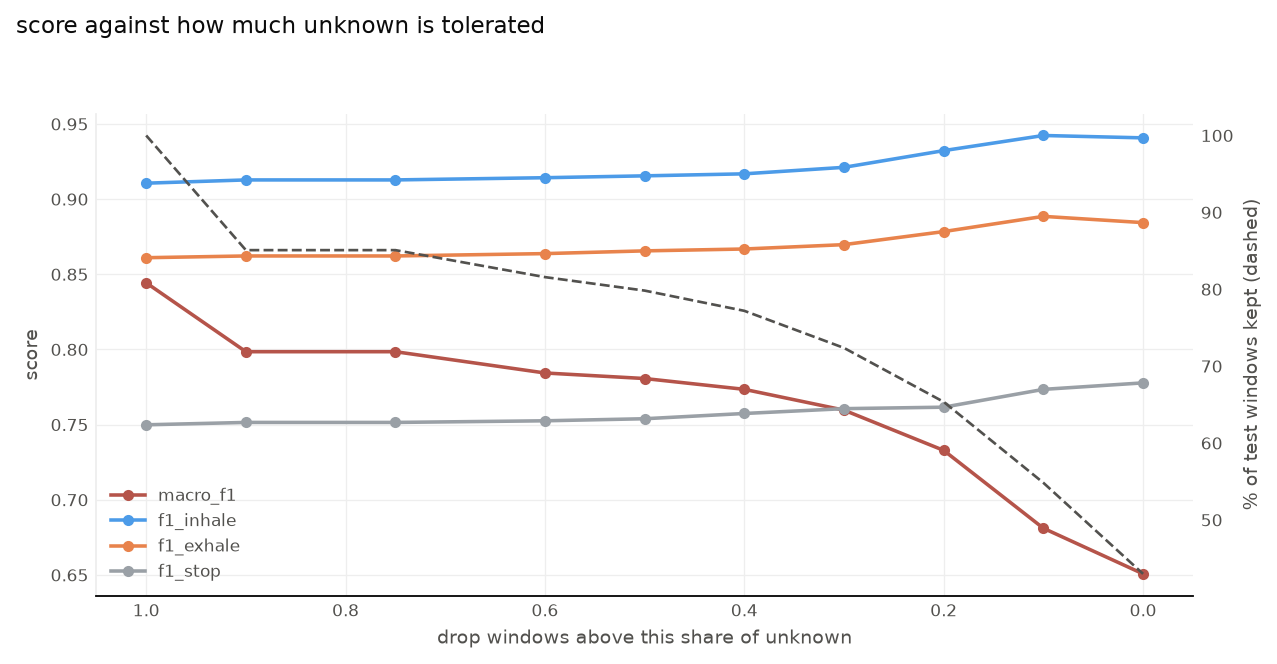

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for column, colour in (('macro_f1', '#B5544A'), ('f1_inhale', '#4C9BE8'),
                       ('f1_exhale', '#E8834C'), ('f1_stop', '#9AA0A6')):
    ax.plot(sweep.threshold, sweep[column], marker='o', markersize=4, linewidth=1.6,
            color=colour, label=column)
ax.set_xlabel('drop windows above this share of unknown', fontsize=8.5, color=INK_SOFT)
ax.set_ylabel('score', fontsize=8.5, color=INK_SOFT)
ax.invert_xaxis()
ax.grid(color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.tick_params(labelsize=7.5, colors=INK_SOFT, length=0)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID)
ax.legend(frameon=False, fontsize=7.5, labelcolor=INK_SOFT, loc='lower left')

twin = ax.twinx()
twin.plot(sweep.threshold, sweep.kept_pct, linestyle='--', linewidth=1.2, color=INK_SOFT)
twin.set_ylabel('% of test windows kept (dashed)', fontsize=8.5, color=INK_SOFT)
twin.tick_params(labelsize=7.5, colors=INK_SOFT, length=0)
for side in ('top', 'right', 'left'):
    twin.spines[side].set_visible(False)

fig.suptitle('score against how much unknown is tolerated', fontsize=10.5, color=INK,
             x=0.01, ha='left', y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(OUT / 'threshold_sweep.png', dpi=160, facecolor=SURFACE, bbox_inches='tight')
plt.close(fig)
Image(filename=str(OUT / 'threshold_sweep.png'))

## Reading it

Two things to keep apart.

A metric rising as the threshold tightens is **not** evidence the model is better. It is a
different, easier test set. The number worth watching is whether the *off-diagonal* confusion
between `inhale`, `exhale` and `stop` changes - that is about phase calling and is not
mechanically improved by dropping unlabelled stretches. The `unknown` column falling **is**
expected, and mostly tautological: windows that are largely unlabelled are exactly the ones
where the model is silent.

If the three-by-three block barely moves, the filter is cosmetic - the phases were already
being called as well on the noisy windows as on the clean ones, and the low headline score was
coming from the `unknown` boundary rather than from phase confusion.